In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 1000)
pd.options.display.float_format = '{:,.2f}'.format

from sklearn import preprocessing
from scipy.stats import chi2_contingency

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
#import category_encoders as ce

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, auc, confusion_matrix

In [2]:
product_target = 'fam_investment'
save_path = 'data/df_' + product_target + '.csv'
save_path

'data/df_fam_investment.csv'

In [3]:
df = pd.read_csv(save_path)
df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')

In [4]:
# Nos quedamos con los clientes vivos para luego descartar los muertos de la predicción:
df_non_deceased_last_partition = df[(df["pk_partition"]==df["pk_partition"].max())&(df["deceased"]=='N')].drop_duplicates()
df_non_deceased_last_partition

,pk_cid,pk_partition,entry_date,entry_channel,active_customer,segment,country_id,region_code,gender,age,deceased,salary,loans,mortgage,em_account_pp,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount,z_months_since_entry,z_pct_months_active,z_partition_segment_changed,z_segment_mode,z_churn_customer_flag,z_new_customer_flag,z_num_products,z_active_with_product,z_num_purchased_products,y
16,1000028,2019-05-01,2017-01-01,KHC,1.00,02 - PARTICULARES,ES,28.00,H,44,N,"133,378.89",0,0,0,0,0.00,0.00,0,0,1,0,1,28.00,1.00,0,02 - PARTICULARES,0,0,2.00,1,0.00,0.00
33,1000096,2019-05-01,2015-01-01,KFA,1.00,02 - PARTICULARES,ES,28.00,H,10,N,0.00,0,0,0,0,0.00,0.00,0,0,0,0,0,53.00,1.00,0,02 - PARTICULARES,0,0,0.00,0,0.00,0.00
56,1000113,2019-05-01,2015-04-01,KAT,0.00,02 - PARTICULARES,ES,14.00,V,54,N,"136,705.50",0,0,0,0,0.00,0.00,0,0,0,0,0,50.00,0.00,0,02 - PARTICULARES,0,0,0.00,0,0.00,0.00
67,1000130,2019-05-01,2018-03-01,KAT,1.00,02 - PARTICULARES,ES,28.00,H,44,N,"126,133.50",0,0,0,0,0.00,0.00,0,0,0,0,0,14.00,0.27,0,02 - PARTICULARES,0,0,0.00,0,0.00,0.00
84,1000157,2019-05-01,2016-03-01,KFC,1.00,02 - PARTICULARES,ES,46.00,V,44,N,"68,038.20",0,0,0,0,0.00,0.00,0,0,0,0,1,39.00,0.94,0,02 - PARTICULARES,0,0,1.00,1,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5781641,998837,2019-05-01,2018-05-01,KAT,1.00,02 - PARTICULARES,ES,41.00,V,37,N,"113,316.87",0,0,0,0,0.00,0.00,0,0,0,0,1,12.00,1.00,0,02 - PARTICULARES,0,0,1.00,1,0.00,0.00
5781658,998859,2019-05-01,2015-05-01,KFC,1.00,02 - PARTICULARES,ES,28.00,V,44,N,"126,242.40",0,0,0,1,1.00,1.00,1,1,1,0,0,49.00,1.00,0,02 - PARTICULARES,0,0,6.00,1,0.00,0.00
5781664,999706,2019-05-01,2018-12-01,KFC,0.00,02 - PARTICULARES,ES,28.00,H,14,N,0.00,0,0,0,0,0.00,0.00,0,0,0,0,0,5.00,0.17,0,02 - PARTICULARES,0,0,0.00,0,0.00,0.00
5781681,999825,2019-05-01,2017-01-01,KFC,1.00,02 - PARTICULARES,ES,48.00,V,40,N,"108,659.43",0,0,0,0,0.00,0.00,0,0,0,0,1,28.00,1.00,0,02 - PARTICULARES,0,0,1.00,1,0.00,0.00


# 1. Features Analysis and Transformation before Modelling

In [5]:
df.head()

,pk_cid,pk_partition,entry_date,entry_channel,active_customer,segment,country_id,region_code,gender,age,deceased,salary,loans,mortgage,em_account_pp,credit_card,payroll,pension_plan,payroll_account,emc_account,debit_card,em_account_p,em_acount,z_months_since_entry,z_pct_months_active,z_partition_segment_changed,z_segment_mode,z_churn_customer_flag,z_new_customer_flag,z_num_products,z_active_with_product,z_num_purchased_products,y
0,1000028,2018-01-01,2017-01-01,KHC,1.00,02 - PARTICULARES,ES,28.00,H,43,N,"133,378.89",0,0,0,0,0.00,0.00,0,0,1,0,1,12.00,1.00,0,02 - PARTICULARES,0,0,2.00,1,0.00,0.00
1,1000028,2018-02-01,2017-01-01,KHC,1.00,02 - PARTICULARES,ES,28.00,H,43,N,"133,378.89",0,0,0,0,0.00,0.00,0,0,1,0,1,13.00,1.00,0,02 - PARTICULARES,0,0,2.00,1,0.00,0.00
2,1000028,2018-03-01,2017-01-01,KHC,1.00,02 - PARTICULARES,ES,28.00,H,43,N,"133,378.89",0,0,0,0,0.00,0.00,0,0,1,0,1,14.00,1.00,0,02 - PARTICULARES,0,0,2.00,1,0.00,0.00
3,1000028,2018-04-01,2017-01-01,KHC,1.00,02 - PARTICULARES,ES,28.00,H,43,N,"133,378.89",0,0,0,0,0.00,0.00,0,0,1,0,1,15.00,1.00,0,02 - PARTICULARES,0,0,2.00,1,0.00,0.00
4,1000028,2018-05-01,2017-01-01,KHC,1.00,02 - PARTICULARES,ES,28.00,H,43,N,"133,378.89",0,0,0,0,0.00,0.00,0,0,1,0,1,16.00,1.00,0,02 - PARTICULARES,0,0,2.00,1,0.00,0.00


In [6]:
# columnas que borramos de partida:
df.drop(columns=['entry_date','z_segment_mode'], inplace=True)

## Global functions

### Correlations

In [7]:
def matriz_correlacion_numeric_features(df):
    numeric_df = df.select_dtypes(include=['number'])

    correlation_matrix = numeric_df.corr(method='pearson')

    plt.figure(figsize=(12, 8))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
    plt.title('Matriz de Correlación (Pearson)')
    plt.show()

In [8]:
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    if min(k-1, r-1) == 0:
        return 0.0 
    return np.sqrt((chi2/n) / (min(k-1, r-1)))

def calculate_cramers_v_matrix(df, columns):
    """
    Calculates Cramér's V matrix for a list of categorical columns in a DataFrame.

    Args:
        df: The input pandas DataFrame.
        columns: A list of column names to calculate the Cramér's V matrix for.

    Returns:
        A pandas DataFrame representing the Cramér's V matrix.
    """
    cramer_matrix = pd.DataFrame(index=columns, columns=columns, dtype=float)

    for col1 in columns:
        for col2 in columns:
            if col1 == col2:
                cramer_matrix.loc[col1, col2] = 1.0
            else:
                cramer_matrix.loc[col1, col2] = cramers_v(
                    df[col1].astype(str), df[col2].astype(str)
                )
    return cramer_matrix

In [9]:
def matriz_correlacion_object_features(dfg,listdf):
  cramer_matrix = calculate_cramers_v_matrix(dfg, listdf)

  plt.figure(figsize=(8,6))
  sns.heatmap(cramer_matrix.astype(float), annot=True, cmap="Blues")
  plt.title("Colinealidad (Cramér's V)")
  plt.show()

### Processing

In [10]:
def group_minor_categories(df, col, threshold):
    """
    Agrupa las categorías poco frecuentes de una columna en 'Other'.
    """
    df[col] = df[col].fillna('Unknown').astype(str)
    value_counts = df[col].value_counts(normalize=True)
    minor_categories = value_counts[value_counts < threshold].index
    df[f"{col}_grouped"] = df[col].replace(minor_categories, 'Other')

    return df


### Feature Engineering

In [11]:
def frequency_encode(df, features_to_encode, normalize=True):
    """
    Aplica Frequency Encoding a una columna categórica,
    crea una nueva columna '<columna>_freq' y elimina la original.
    """

    for feature in features_to_encode:
        freq_encoding = df[feature].value_counts(normalize=normalize)
        new_column_name = f"{feature}_freq"
        df[new_column_name] = df[feature].map(freq_encoding)
        df.drop(columns=[feature], inplace=True)
        
    return df

In [12]:
def one_hot_encode(df, features_to_encode):
    """
    Applies one-hot encoding to a list of specified features in a DataFrame using scikit-learn.
    """
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    encoded = encoder.fit_transform(df[features_to_encode])
    
    encoded_df = pd.DataFrame(
        encoded, 
        columns=encoder.get_feature_names_out(features_to_encode),
        index=df.index
    )
    
    df = df.drop(columns=features_to_encode)
    df = pd.concat([df, encoded_df], axis=1)

    return df

In [13]:
def normalize_features(df, features_to_normalize):
    """
    Normalizes a list of specified features in a DataFrame to a range between 0 and 1.
    """

    scaler = MinMaxScaler()
    df[features_to_normalize] = scaler.fit_transform(df[features_to_normalize])
    
    return df

----------------------------------------------------------

In [14]:
stats = []
for col in df.columns:
    stats.append((col, df[col].nunique(), df[col].isnull().sum() * 100 / df.shape[0], df[col].value_counts(normalize=True, dropna=False).values[0] * 100, df[col].dtype))

stats_df = pd.DataFrame(stats, columns=['Feature', 'Unique_values', '% missing values', '% values in biggest category', 'type'])
stats_df = stats_df.sort_values(by=[ '% values in biggest category','Unique_values'], ascending=[False, True])

In [15]:
filtered_stats_categoricas = stats_df[(stats_df['type'] != 'object')]
display(filtered_stats_categoricas)

,Feature,Unique_values,% missing values,% values in biggest category,type
13,em_account_pp,1,0.00,100.00,int64
20,em_account_p,2,0.00,100.00,int64
12,mortgage,2,0.00,99.99,int64
11,loans,2,0.00,99.99,int64
30,y,2,0.00,99.93,float64
25,z_churn_customer_flag,2,0.00,99.78,int64
24,z_partition_segment_changed,2,0.00,99.00,int64
14,credit_card,2,0.00,98.91,int64
26,z_new_customer_flag,2,0.00,97.56,int64
29,z_num_purchased_products,7,0.00,96.80,float64


In [16]:
filtered_stats_categoricas = stats_df[(stats_df['type'] == 'object')]
display(filtered_stats_categoricas)

,Feature,Unique_values,% missing values,% values in biggest category,type
9,deceased,2,0.00,99.99,object
5,country_id,39,0.00,99.97,object
4,segment,3,0.00,69.52,object
2,entry_channel,64,0.00,56.06,object
7,gender,2,0.00,52.09,object
1,pk_partition,17,0.00,7.46,object


Decisiones:
- Borramos "deceased" por tener el 99% de los registros con el mismo valor
- Borramos "country_id" por tener el 99% de los registros con el mismo. Dejamos el region_code que está relleno cuando el pais es España y hay mas variabilidad.
- "segment" y "gender" OHE 
- "entry_channel" agrupar y luego OHE

In [17]:
df.drop(columns=['deceased','country_id'], inplace=True)

### 1.0 Correlations

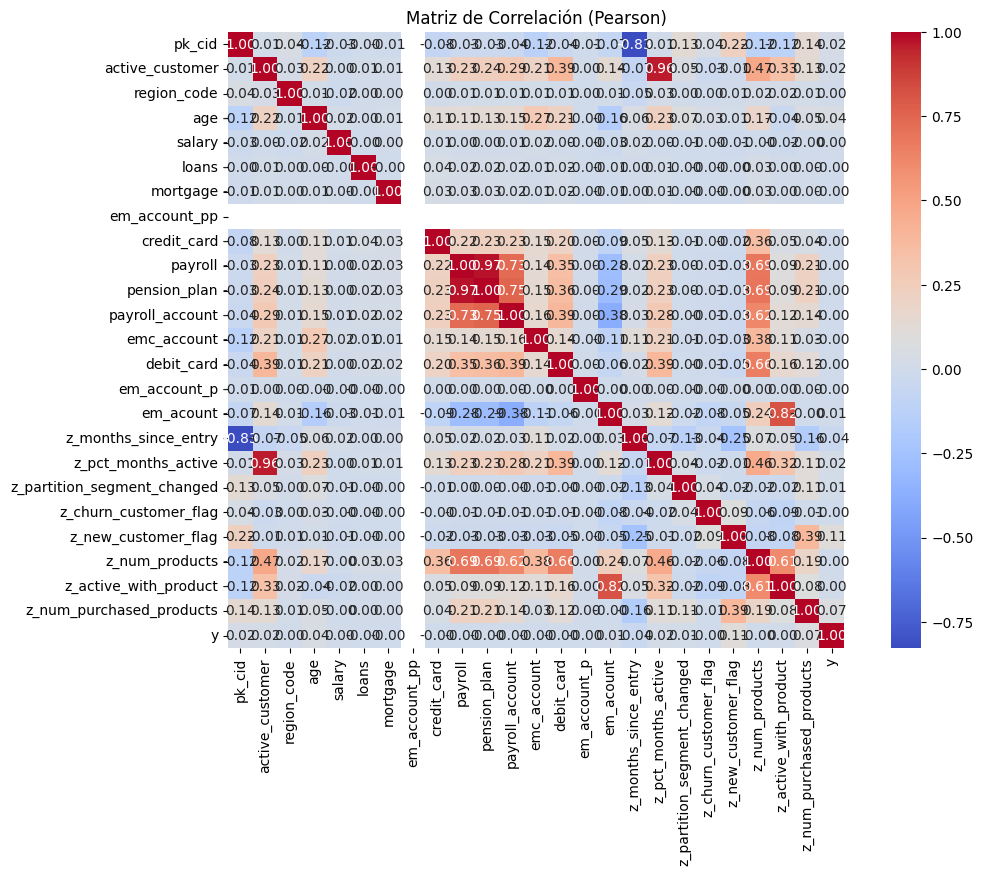

In [18]:
matriz_correlacion_numeric_features(df)

In [19]:
df.em_acount.value_counts(normalize=True)

em_acount
1   0.74
0   0.26
Name: proportion, dtype: float64

In [20]:
# Borramos "z_pct_months_active" por estar al 90% correlada con "active_customer" y "payroll_account" porque es igual que "payroll", borramos 'payroll' por altisima correlacion con pension plan
df.drop(columns=['z_pct_months_active', 'payroll_account', 'payroll', 'em_account_pp', 'em_account_p'], inplace=True)

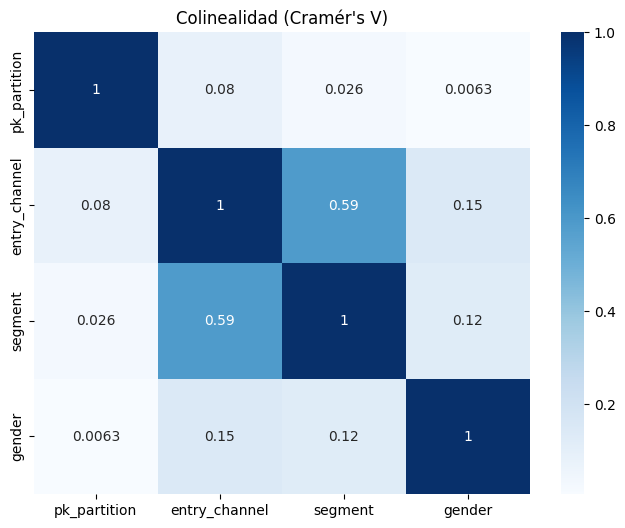

In [21]:
object_cols= df.select_dtypes(exclude=['number']).columns
matriz_correlacion_object_features(df, object_cols)

### 1.1 Fechas - estacionalidad 

In [22]:
df['pk_partition'] = pd.to_datetime(df['pk_partition'])

# Variables temporales
df['month'] = df['pk_partition'].dt.month
df['day_of_year'] = df['pk_partition'].dt.dayofyear
df['weekday'] = df['pk_partition'].dt.weekday  # 0 = lunes, 6 = domingo

# Transformación cíclica (reloj):
# Mes (12 meses)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
# Día del año (365 días)
df['dayofyear_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['dayofyear_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)
# Día de la semana (7 días)
df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)

In [23]:
df.drop(columns={'month','day_of_year','weekday'}, inplace = True)

### 1.2 Encoding

In [24]:
df = group_minor_categories(df, 'entry_channel', 0.01)
df.drop(columns='entry_channel', inplace=True)

df.rename(columns={'entry_channel_grouped':'entry_channel'}, inplace=True)

In [25]:
# df = group_minor_categories(df, 'region_code', 0.005)
# df.drop(columns='region_code', inplace=True)

Mejor no agrupamos la región y le hacemos el Frequency Encoding que consideramos que nos va a aportar más información.

In [26]:
# Frequency Encoding:
freqenc_cols = ['region_code']
df = frequency_encode(df, freqenc_cols)

In [27]:
# One Hot Encoding:
ohe_cols = ['entry_channel','segment','gender']
df = one_hot_encode(df, ohe_cols)

### 1.3 Normalization

In [28]:
normalize_cols = ['age','salary','z_months_since_entry','z_num_products','z_num_purchased_products']

df = normalize_features(df, normalize_cols)

# 2. Modelling

In [29]:
# reordenamos dejando el target al final
col = df.pop("y")
df["y"] = col

In [30]:
print(df.shape)

(5785625, 42)


In [31]:
# localizamos la última partición:
max_partition = df.pk_partition.max()

# 1. la guardamos en otro df para la predicción final
df_last_partition = df[df["pk_partition"]==max_partition] 
# 2. borramos los registros de la última partición porque no sabemos lo que pasa al mes siguiente
df = df[df["pk_partition"]!=max_partition]
print(df.shape)

(5354190, 42)


In [32]:
# localizamos la penúltima partición (SET DE VALIDACIÓN):
unique_parts = sorted(df.pk_partition.unique())
second_last_partition = unique_parts[-1]

# 1. la guardamos en otro df_val 
df_val = df[df["pk_partition"]==second_last_partition] 
# 2. borramos los registros de la partición de validación
df = df[df["pk_partition"]!=second_last_partition]
print(df.shape)

(4926271, 42)


In [33]:
df.head()

,pk_cid,pk_partition,active_customer,age,salary,loans,mortgage,credit_card,pension_plan,emc_account,debit_card,em_acount,z_months_since_entry,z_partition_segment_changed,z_churn_customer_flag,z_new_customer_flag,z_num_products,z_active_with_product,z_num_purchased_products,month_sin,month_cos,dayofyear_sin,dayofyear_cos,weekday_sin,weekday_cos,region_code_freq,entry_channel_KAT,entry_channel_KFA,entry_channel_KFC,entry_channel_KHD,entry_channel_KHE,entry_channel_KHK,entry_channel_KHM,entry_channel_KHN,entry_channel_KHQ,entry_channel_Other,segment_01 - TOP,segment_02 - PARTICULARES,segment_03 - UNIVERSITARIO,gender_H,gender_V,y
0,1000028,2018-01-01,1.00,0.40,0.00,0,0,0,0.00,0,1,1,0.23,0,0,0,0.25,1,0.00,0.50,0.87,0.02,1.00,0.00,1.00,0.19,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00
1,1000028,2018-02-01,1.00,0.40,0.00,0,0,0,0.00,0,1,1,0.25,0,0,0,0.25,1,0.00,0.87,0.50,0.52,0.85,0.43,-0.90,0.19,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00
2,1000028,2018-03-01,1.00,0.40,0.00,0,0,0,0.00,0,1,1,0.26,0,0,0,0.25,1,0.00,1.00,0.00,0.86,0.51,0.43,-0.90,0.19,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00
3,1000028,2018-04-01,1.00,0.40,0.00,0,0,0,0.00,0,1,1,0.28,0,0,0,0.25,1,0.00,0.87,-0.50,1.00,0.00,-0.78,0.62,0.19,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00
4,1000028,2018-05-01,1.00,0.40,0.00,0,0,0,0.00,0,1,1,0.30,0,0,0,0.25,1,0.00,0.50,-0.87,0.87,-0.49,0.78,0.62,0.19,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00


In [34]:
df.y.value_counts()

y
0.00    4922375
1.00       3896
Name: count, dtype: int64

### 2.1 Undersampling

In [35]:
df_model = df.copy()

df_pos = df_model[df_model["y"] == 1]
df_neg = df_model[df_model["y"] == 0]

ratio = 3 
df_neg_sample = df_neg.sample(n=len(df_pos)*ratio, random_state=42)

df_balanced = pd.concat([df_pos, df_neg_sample], ignore_index=True).sample(frac=1, random_state=42)

X_bal = df_balanced.drop(columns=["y", "pk_cid", "pk_partition"])
y_bal = df_balanced["y"]

In [36]:
df_balanced.y.value_counts(normalize=True)

y
0.00   0.75
1.00   0.25
Name: proportion, dtype: float64

### 2.2 Model

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X_bal, y_bal, test_size=0.2, random_state=42, stratify=y_bal)

model_us = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    use_label_encoder=False
)

model_us.fit(X_train, y_train)

/Users/martadom/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:18:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


### 2.3 Feature Importance

Hacemos este análisis para entender cuales son las variables que más poder tienen en la predicción.

In [38]:
importances = model_us.feature_importances_

In [39]:
feat_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
})

feat_importances.sort_values(by='importance', ascending=False).head(20)

,feature,importance
13,z_new_customer_flag,0.24
10,z_months_since_entry,0.18
32,entry_channel_KHQ,0.10
26,entry_channel_KFC,0.08
36,segment_03 - UNIVERSITARIO,0.08
34,segment_01 - TOP,0.03
1,age,0.03
0,active_customer,0.02
28,entry_channel_KHE,0.02
16,z_num_purchased_products,0.02


### 2.4 Evaluation

* Con el dataset balanceado:

In [40]:
y_pred_train = model_us.predict(X_train)
y_pred_test  = model_us.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, y_pred_train))
print("Test accuracy:", accuracy_score(y_test, y_pred_test))
print("F1 score:", f1_score(y_test, y_pred_test))

Train accuracy: 0.9943049651078848
Test accuracy: 0.960538979788258
F1 score: 0.922003804692454


In [41]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

y_pred = model_us.predict(X_test)

# Confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

recall_positivos = tp / (tp + fn) * 100
accuracy_total = (tp + tn) / (tp + tn + fp + fn) * 100

# Prints (como los tenías)
print(f"Verdaderos positivos (1s acertados): {tp}")
print(f"Falsos negativos (1s perdidos): {fn}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 score: {f1}")
print(f"% de 1s acertados (recall): {recall_positivos:.2f}%")
print(f"% de aciertos total (accuracy): {accuracy_total:.2f}%")

Verdaderos positivos (1s acertados): 727
Falsos negativos (1s perdidos): 52
Precision: 0.9110275689223057
Recall: 0.9332477535301669
F1 score: 0.922003804692454
% de 1s acertados (recall): 93.32%
% de aciertos total (accuracy): 96.05%


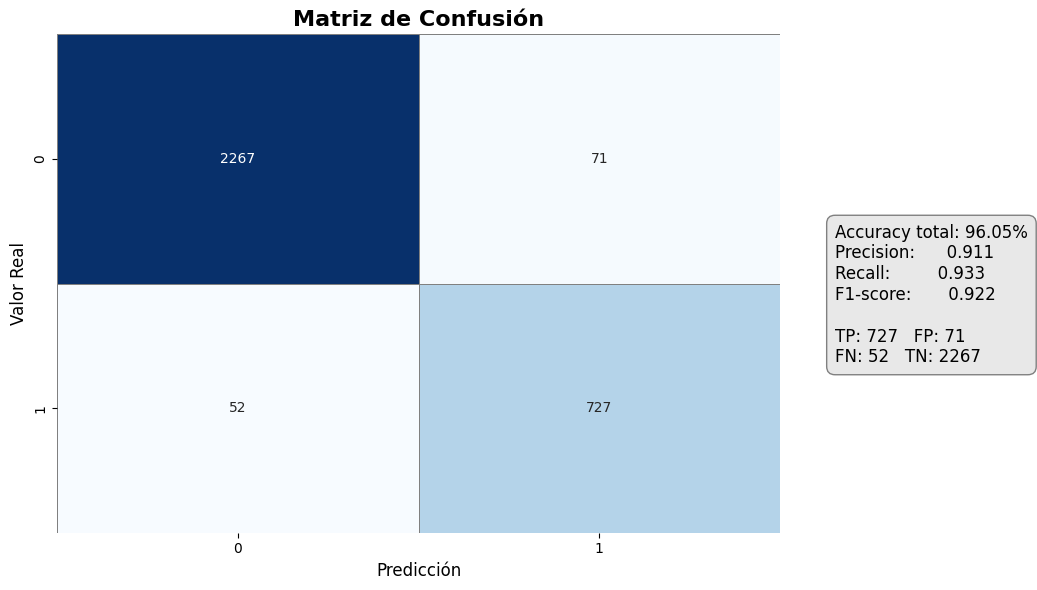

In [42]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Matriz de Confusión", fontsize=16, fontweight="bold")
plt.xlabel("Predicción", fontsize=12)
plt.ylabel("Valor Real", fontsize=12)

# Panel lateral con métricas
metrics_text = (
    f"Accuracy total: {accuracy_total:.2f}%\n"
    f"Precision:      {precision:.3f}\n"
    f"Recall:         {recall:.3f}\n"
    f"F1-score:       {f1:.3f}\n\n"
    f"TP: {tp}   FP: {fp}\n"
    f"FN: {fn}   TN: {tn}"
)

plt.gcf().text(
    1.05, 0.5, metrics_text,
    fontsize=12,
    verticalalignment='center',
    bbox=dict(boxstyle="round,pad=0.5", fc="#e8e8e8", ec="gray")
)

plt.tight_layout()
plt.show()

ROC AUC: 0.9913161024366086


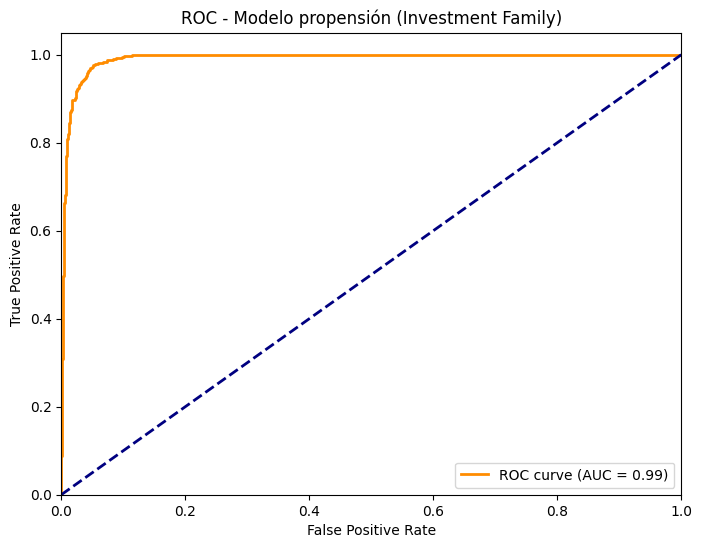

In [43]:
y_prob_test = model_us.predict_proba(X_test)[:,1]
print("ROC AUC:", roc_auc_score(y_test, y_prob_test))

fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Modelo propensión (Investment Family)')
plt.legend(loc="lower right")
plt.show()

In [44]:
y_prob_test

array([4.9128954e-05, 4.2666692e-02, 9.9937326e-01, ..., 1.5694629e-04,
       1.5898109e-05, 7.2727107e-06], dtype=float32)

* Con el dataset total (sin balanceo):

In [45]:
X_full = df.drop(columns=["y", "pk_cid", "pk_partition"])
y_full = df["y"]

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)

In [46]:
y_pred_train_full = model_us.predict(X_train_full)
y_pred_test_full  = model_us.predict(X_test_full)

print("Train accuracy:", accuracy_score(y_train_full, y_pred_train_full))
print("Test accuracy:", accuracy_score(y_test_full, y_pred_test_full))
print("F1 score:", f1_score(y_test_full, y_pred_test_full))

y_pred_full = y_pred_test_full 

tn_full, fp_full, fn_full, tp_full = confusion_matrix(y_test_full, y_pred_full).ravel()

precision_full = precision_score(y_test_full, y_pred_full)
recall_full = recall_score(y_test_full, y_pred_full)
f1_full = f1_score(y_test_full, y_pred_full)

recall_positivos_full = tp_full / (tp_full + fn_full) * 100
accuracy_total_full = (tp_full + tn_full) / (tp_full + tn_full + fp_full + fn_full) * 100

# Prints (igual que los tuyos)
print(f"Verdaderos positivos (1s acertados): {tp_full}")
print(f"Falsos negativos (1s perdidos): {fn_full}")
print(f"Precision: {precision_full}")
print(f"Recall: {recall_full}")
print(f"F1 score: {f1_full}")
print(f"% de 1s acertados (recall): {recall_positivos_full:.2f}%")
print(f"% de aciertos total (accuracy): {accuracy_total_full:.2f}%")

Train accuracy: 0.9694868023880137
Test accuracy: 0.9693429619743112
F1 score: 0.048031769044092155
Verdaderos positivos (1s acertados): 762
Falsos negativos (1s perdidos): 17
Precision: 0.024620355411954765
Recall: 0.9781771501925546
F1 score: 0.048031769044092155
% de 1s acertados (recall): 97.82%
% de aciertos total (accuracy): 96.93%


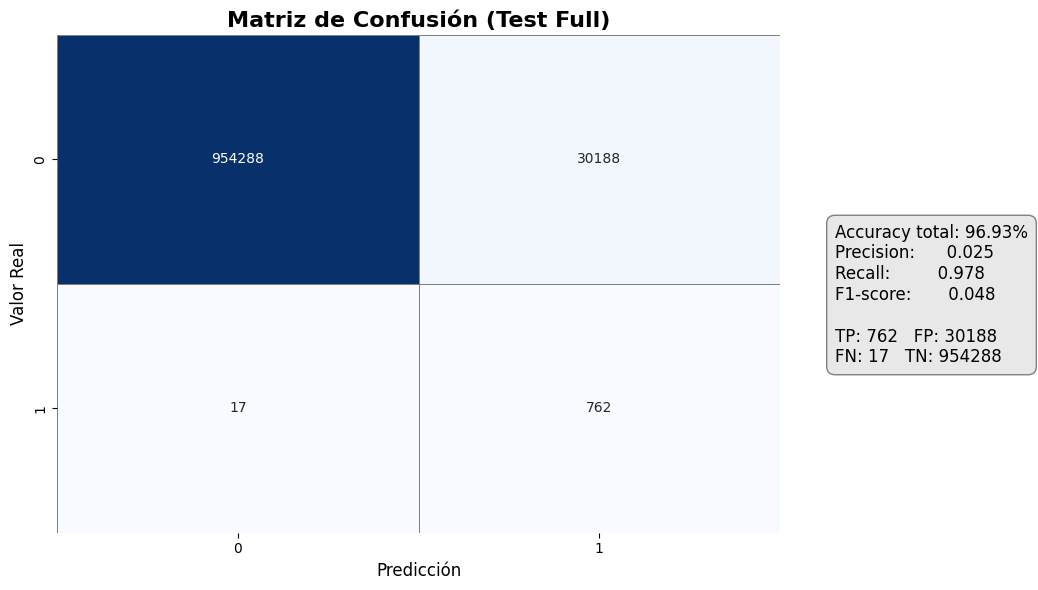

In [47]:
cm_full = confusion_matrix(y_test_full, y_pred_full)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_full,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Matriz de Confusión (Test Full)", fontsize=16, fontweight="bold")
plt.xlabel("Predicción", fontsize=12)
plt.ylabel("Valor Real", fontsize=12)

# Panel lateral con métricas
metrics_text_full = (
    f"Accuracy total: {accuracy_total_full:.2f}%\n"
    f"Precision:      {precision_full:.3f}\n"
    f"Recall:         {recall_full:.3f}\n"
    f"F1-score:       {f1_full:.3f}\n\n"
    f"TP: {tp_full}   FP: {fp_full}\n"
    f"FN: {fn_full}   TN: {tn_full}"
)

plt.gcf().text(
    1.05, 0.5, metrics_text_full,
    fontsize=12,
    verticalalignment='center',
    bbox=dict(boxstyle="round,pad=0.5", fc="#e8e8e8", ec="gray")
)

plt.tight_layout()
plt.show()

ROC AUC: 0.9940686424005177


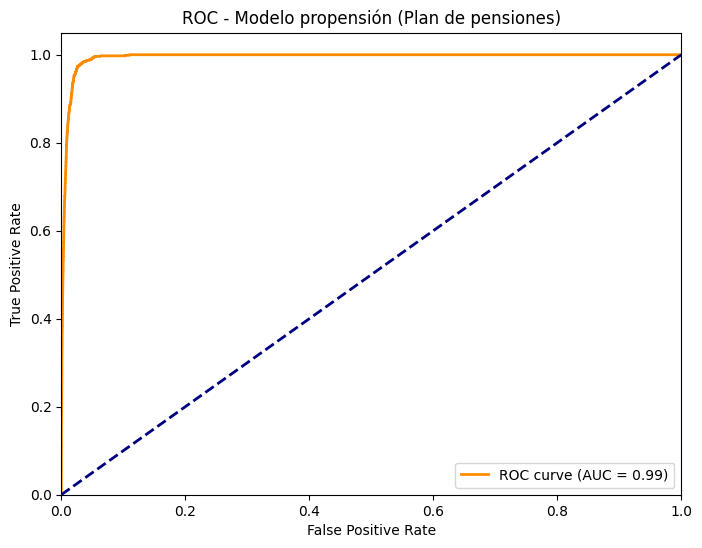

In [48]:
y_prob_test_full = model_us.predict_proba(X_test_full)[:,1]
print("ROC AUC:", roc_auc_score(y_test_full, y_prob_test_full))

fpr, tpr, thresholds = roc_curve(y_test_full, y_prob_test_full)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Modelo propensión (Plan de pensiones)')
plt.legend(loc="lower right")
plt.show()

* Con el set de validación (penúltima partición abril 2019)

Verdaderos positivos (1s acertados): 25
Falsos negativos (1s perdidos): 9
Precision: 0.0023721415694088624
Recall: 0.7352941176470589
F1 score: 0.004729026766291497
% de 1s acertados (recall): 73.53%
% de aciertos total (accuracy): 97.54%


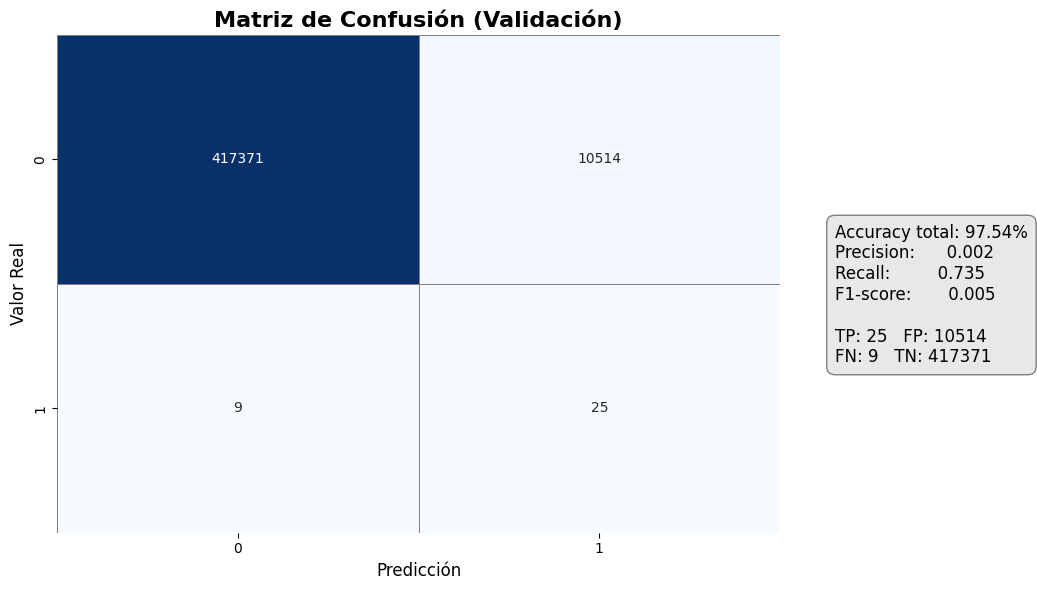

In [49]:
# Separación features / target
X_val = df_val.drop(columns=["y", "pk_cid", "pk_partition"])
y_val = df_val["y"]

# Predicciones
y_pred_val = model_us.predict(X_val)

# Métricas principales
tn_val, fp_val, fn_val, tp_val = confusion_matrix(y_val, y_pred_val).ravel()

precision_val = precision_score(y_val, y_pred_val)
recall_val = recall_score(y_val, y_pred_val)
f1_val = f1_score(y_val, y_pred_val)

recall_positivos_val = tp_val / (tp_val + fn_val) * 100
accuracy_total_val = (tp_val + tn_val) / (tp_val + tn_val + fp_val + fn_val) * 100

# Impresiones
print(f"Verdaderos positivos (1s acertados): {tp_val}")
print(f"Falsos negativos (1s perdidos): {fn_val}")
print(f"Precision: {precision_val}")
print(f"Recall: {recall_val}")
print(f"F1 score: {f1_val}")
print(f"% de 1s acertados (recall): {recall_positivos_val:.2f}%")
print(f"% de aciertos total (accuracy): {accuracy_total_val:.2f}%")

# Matriz de confusión
cm_val = confusion_matrix(y_val, y_pred_val)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_val,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Matriz de Confusión (Validación)", fontsize=16, fontweight="bold")
plt.xlabel("Predicción", fontsize=12)
plt.ylabel("Valor Real", fontsize=12)

# Panel lateral con métricas
metrics_text_val = (
    f"Accuracy total: {accuracy_total_val:.2f}%\n"
    f"Precision:      {precision_val:.3f}\n"
    f"Recall:         {recall_val:.3f}\n"
    f"F1-score:       {f1_val:.3f}\n\n"
    f"TP: {tp_val}   FP: {fp_val}\n"
    f"FN: {fn_val}   TN: {tn_val}"
)

plt.gcf().text(
    1.05, 0.5, metrics_text_val,
    fontsize=12,
    verticalalignment='center',
    bbox=dict(boxstyle="round,pad=0.5", fc="#e8e8e8", ec="gray")
)

plt.tight_layout()
plt.show()


ROC AUC: 0.9632373046908563


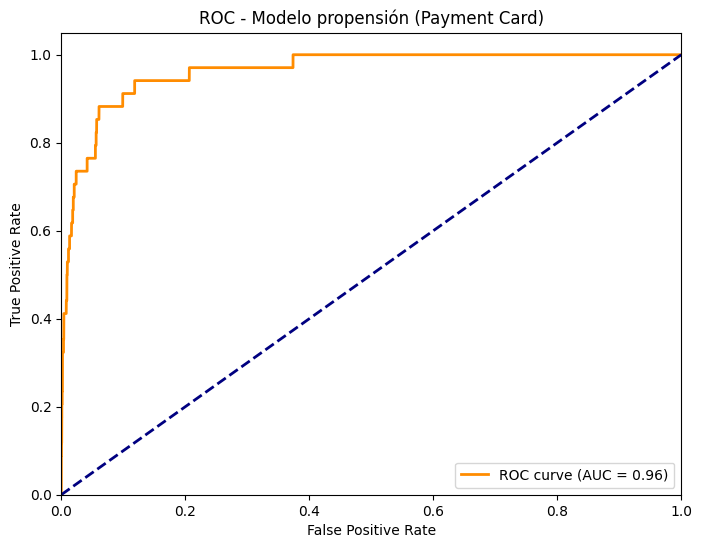

In [50]:
y_prob_val = model_us.predict_proba(X_val)[:,1]
print("ROC AUC:", roc_auc_score(y_val, y_prob_val))

fpr, tpr, thresholds = roc_curve(y_val, y_prob_val)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Modelo propensión (Payment Card)')
plt.legend(loc="lower right")
plt.show()

In [51]:
df_pred_val = pd.DataFrame({
    "pk_cid": df_val["pk_cid"].values,
    "y_real": y_val.values,
    "y_pred": y_pred_val,
    "propension": y_prob_val
})

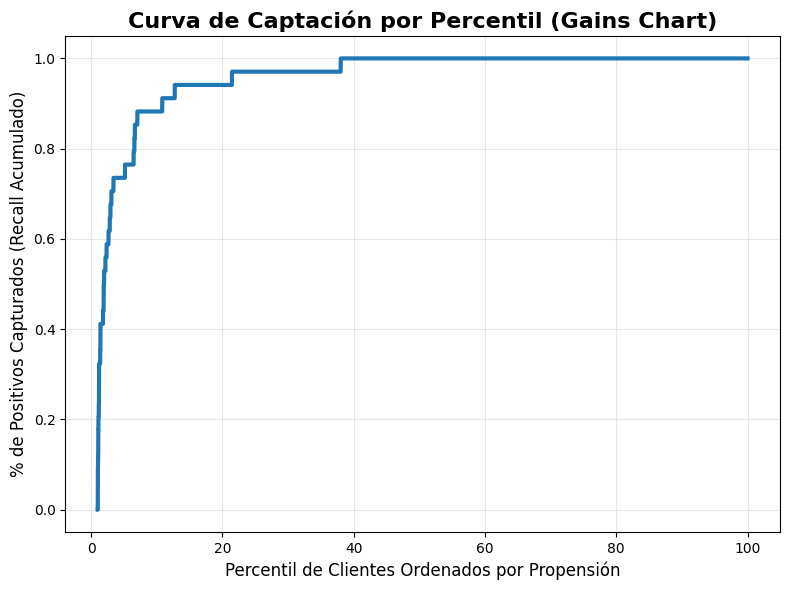

In [52]:
# Asegurar orden por propensión (de mayor a menor)
df_sorted = df_pred_val.sort_values("propension", ascending=False).reset_index(drop=True)

# Crear percentiles 1–100
df_sorted["percentil"] = np.linspace(0.01, 1.00, len(df_sorted))

# Cálculo de captación acumulada (recall progresivo)
df_sorted["captados"] = df_sorted["y_real"].cumsum()
total_positivos = df_sorted["y_real"].sum()

df_sorted["recall_acumulado"] = df_sorted["captados"] / total_positivos

# Plot
plt.figure(figsize=(8, 6))
plt.plot(df_sorted["percentil"] * 100, df_sorted["recall_acumulado"], linewidth=3)

plt.title("Curva de Captación por Percentil (Gains Chart)", fontsize=16, fontweight="bold")
plt.xlabel("Percentil de Clientes Ordenados por Propensión", fontsize=12)
plt.ylabel("% de Positivos Capturados (Recall Acumulado)", fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Total clientes: 427919
Total positivos reales: 34
Tasa base (positivos / total): 0.0001

Percentil óptimo según F1: top 1%  → F1=0.0083, recall=0.529, precision=0.0042, clientes=4280.0
Para captar el 85% de los positivos necesitas el top 6% → clientes=25676, positivos_capturados≈29
Para captar el 90% de los positivos necesitas el top 10% → clientes=42792, positivos_capturados≈31

--- Primeros percentiles ---
 percentil  clientes_contactados  positivos_capturados  recall_acumulado  precision_en_topk  lift  f1_topk
         1                  4280                    18              0.53               0.00 52.93     0.01
         2                  8559                    23              0.68               0.00 33.82     0.01
         3                 12838                    25              0.74               0.00 24.51     0.00
         4                 17117                    25              0.74               0.00 18.38     0.00
         5                 21396                    2

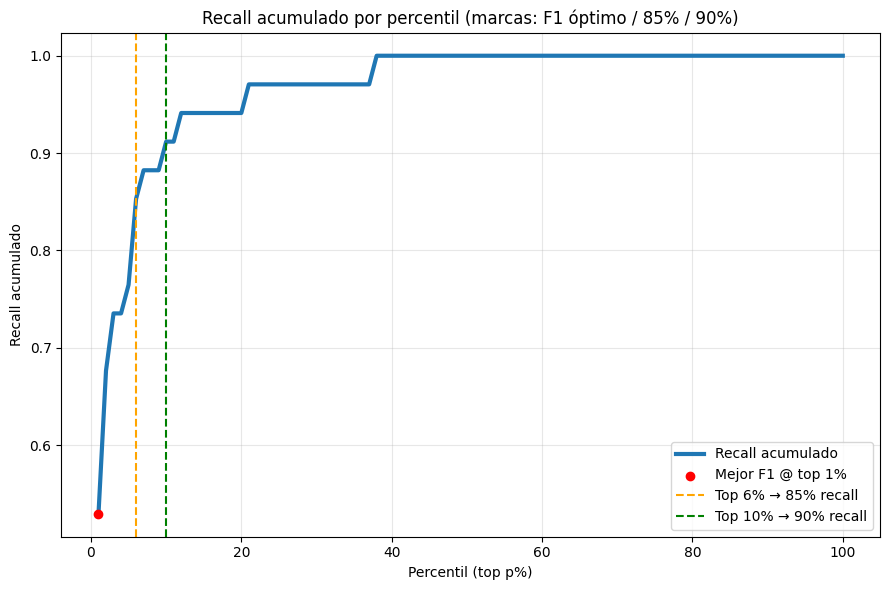


--- Percentiles (muestra) ---
 percentil  clientes_contactados  positivos_capturados  recall_acumulado  precision_en_topk  lift  f1_topk
         1                  4280                    18              0.53               0.00 52.93     0.01
         2                  8559                    23              0.68               0.00 33.82     0.01
         3                 12838                    25              0.74               0.00 24.51     0.00
         4                 17117                    25              0.74               0.00 18.38     0.00
         5                 21396                    26              0.76               0.00 15.29     0.00
         6                 25676                    29              0.85               0.00 14.22     0.00
         7                 29955                    30              0.88               0.00 12.60     0.00
         8                 34234                    30              0.88               0.00 11.03     0.00
      

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------- Asegurarse de tener df_pred_val
# df_pred_val debe contener columnas: "pk_cid", "y_real", "propension"
# Si no existe, crear a partir de df_val y el modelo como en pasos anteriores.

# Ordenar por propensión descendente
df_sorted = df_pred_val.sort_values("propension", ascending=False).reset_index(drop=True)
n_total = len(df_sorted)
total_positivos = df_sorted["y_real"].sum()
overall_rate = total_positivos / n_total

results = []

for p in range(1, 101):  # percentiles 1..100
    cutoff_idx = int(np.ceil((p/100) * n_total))  # número de clientes en el top p%
    if cutoff_idx == 0:
        cutoff_idx = 1
    topk = df_sorted.iloc[:cutoff_idx]

    clientes_contactados = len(topk)
    positivos_capturados = int(topk["y_real"].sum())
    recall_acumulado = positivos_capturados / total_positivos if total_positivos > 0 else 0.0
    precision_en_topk = positivos_capturados / clientes_contactados if clientes_contactados > 0 else 0.0
    lift = (precision_en_topk / overall_rate) if overall_rate > 0 else np.nan

    # F1 para este punto (considerando que la "predicción positiva" son los del top p%)
    if precision_en_topk + recall_acumulado > 0:
        f1_topk = 2 * precision_en_topk * recall_acumulado / (precision_en_topk + recall_acumulado)
    else:
        f1_topk = 0.0

    results.append({
        "percentil": p,
        "clientes_contactados": clientes_contactados,
        "positivos_capturados": positivos_capturados,
        "recall_acumulado": recall_acumulado,
        "precision_en_topk": precision_en_topk,
        "lift": lift,
        "f1_topk": f1_topk
    })

df_percentiles = pd.DataFrame(results)

# Tabla deciles (10% por bloque) con métricas por bloque y acumuladas
deciles = []
for d in range(1, 11):
    p_low = (d-1)*10
    p_high = d*10
    idx_low = int(np.floor(p_low/100 * n_total))
    idx_high = int(np.ceil(p_high/100 * n_total))
    block = df_sorted.iloc[idx_low:idx_high]
    block_clients = len(block)
    block_positives = block["y_real"].sum()
    block_precision = block_positives / block_clients if block_clients>0 else 0
    # acumulado hasta este decil
    acum = df_sorted.iloc[:idx_high]
    acum_positivos = acum["y_real"].sum()
    acum_recall = acum_positivos / total_positivos if total_positivos>0 else 0

    deciles.append({
        "decil": d,
        "rango_percentil": f"{p_low+1}-{p_high}",
        "clientes_en_decil": block_clients,
        "positivos_en_decil": int(block_positives),
        "precision_decil": block_precision,
        "recall_acumulado_hasta_decil": acum_recall
    })

df_deciles = pd.DataFrame(deciles)

# Buscar percentil óptimo por F1
best_row = df_percentiles.loc[df_percentiles["f1_topk"].idxmax()]
best_percentil = int(best_row["percentil"])
best_f1 = best_row["f1_topk"]
best_recall = best_row["recall_acumulado"]
best_precision = best_row["precision_en_topk"]
best_clients = best_row["clientes_contactados"]

# Percentiles necesarios para alcanzar X% recall
def percentil_para_recall(objetivo_recall):
    # primer percentil con recall_acumulado >= objetivo
    df_tmp = df_percentiles[df_percentiles["recall_acumulado"] >= objetivo_recall]
    if len(df_tmp) == 0:
        return None
    row = df_tmp.iloc[0]
    return int(row["percentil"]), int(row["clientes_contactados"]), int(row["positivos_capturados"])

p85 = percentil_para_recall(0.85)
p90 = percentil_para_recall(0.90)

# Mostrar resultados clave
print("Total clientes:", n_total)
print("Total positivos reales:", int(total_positivos))
print("Tasa base (positivos / total): {:.4f}".format(overall_rate))
print()
print(f"Percentil óptimo según F1: top {best_percentil}%  → F1={best_f1:.4f}, recall={best_recall:.3f}, precision={best_precision:.4f}, clientes={best_clients}")
if p85:
    print(f"Para captar el 85% de los positivos necesitas el top {p85[0]}% → clientes={p85[1]}, positivos_capturados≈{p85[2]}")
else:
    print("No se alcanza 85% de recall en 100% (imposible si hay positivos).")
if p90:
    print(f"Para captar el 90% de los positivos necesitas el top {p90[0]}% → clientes={p90[1]}, positivos_capturados≈{p90[2]}")
else:
    print("No se alcanza 90% de recall con el rango 1-100%.")

# Mostrar primeras filas de las tablas
print("\n--- Primeros percentiles ---")
print(df_percentiles.head(10).to_string(index=False))

print("\n--- Tabla deciles ---")
print(df_deciles.to_string(index=False))

# Plot de recall acumulado + marcar cortes
plt.figure(figsize=(9,6))
plt.plot(df_percentiles["percentil"], df_percentiles["recall_acumulado"], linewidth=3, label="Recall acumulado")
plt.scatter([best_percentil], [best_recall], color='red', zorder=5, label=f"Mejor F1 @ top {best_percentil}%")
if p85:
    plt.axvline(p85[0], color='orange', linestyle='--', label=f"Top {p85[0]}% → 85% recall")
if p90:
    plt.axvline(p90[0], color='green', linestyle='--', label=f"Top {p90[0]}% → 90% recall")
plt.xlabel("Percentil (top p%)")
plt.ylabel("Recall acumulado")
plt.title("Recall acumulado por percentil (marcas: F1 óptimo / 85% / 90%)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Devolver tablas para inspección
df_percentiles_display = df_percentiles.copy()
df_percentiles_display["recall_acumulado"] = df_percentiles_display["recall_acumulado"].round(4)
df_percentiles_display["precision_en_topk"] = df_percentiles_display["precision_en_topk"].round(4)
df_percentiles_display["lift"] = df_percentiles_display["lift"].round(2)
df_percentiles_display["f1_topk"] = df_percentiles_display["f1_topk"].round(4)

print("\n--- Percentiles (muestra) ---")
print(df_percentiles_display.head(20).to_string(index=False))

# Si quieres exportar:
# df_percentiles.to_csv("percentiles_metrics.csv", index=False)
# df_deciles.to_csv("deciles_metrics.csv", index=False)


In [54]:
# CRUZAMOS CON CLUSTERING
df_clustering = pd.read_csv('../clustering/data/processed/df_clustered.csv')
df_pred_val_clustered = df_pred_val.merge(df_clustering, on='pk_cid', how='left')
df_sorted_clustered = df_pred_val_clustered.sort_values("propension", ascending=False).reset_index(drop=True)
df_sorted_clustered["percentil"] = np.linspace(0.01, 1.00, len(df_sorted_clustered))
df_sorted_clustered

,pk_cid,y_real,y_pred,propension,cluster_name,percentil
0,1532610,0.00,1,1.00,Particulares Premium Digitales,0.01
1,313527,0.00,1,1.00,Particulares Premium Digitales,0.01
2,1530308,0.00,1,1.00,Particulares Premium Digitales,0.01
3,860425,0.00,1,1.00,Particulares sin cuenta,0.01
4,1534807,0.00,1,1.00,Particulares sin cuenta,0.01
...,...,...,...,...,...,...
427914,1316540,0.00,0,0.00,Jóvenes Potenciales,1.00
427915,1326571,0.00,0,0.00,Jóvenes Potenciales,1.00
427916,1175892,0.00,0,0.00,Jóvenes Potenciales,1.00
427917,1320128,0.00,0,0.00,Jóvenes Potenciales,1.00


In [55]:
cluster_stats = []
total_positivos = tp_val + fn_val  # positivos reales = verdaderos positivos + falsos negativos

for p in range(1, 101):  # percentiles 1..100
    cutoff_idx = int(np.ceil((p/100) * len(df_sorted_clustered)))
    topk = df_sorted_clustered.iloc[:cutoff_idx]
    
    cluster_counts = topk["cluster_name"].value_counts(normalize=False)
    cluster_recall = topk.groupby("cluster_name")["y_real"].sum()
    
    for cluster in df_sorted_clustered["cluster_name"].unique():
        cluster_stats.append({
            "percentil": p,
            "cluster": cluster,
            "clientes_en_top_p": int(cluster_counts.get(cluster, 0)),
            "positivos_capturados": int(cluster_recall.get(cluster, 0)),
            "recall_cluster": cluster_recall.get(cluster, 0) / total_positivos if total_positivos>0 else 0,
            "pct_clientes": cluster_counts.get(cluster, 0) / cutoff_idx if cutoff_idx>0 else 0
        })

df_clusters_percentiles = pd.DataFrame(cluster_stats)
df_clusters_percentiles

,percentil,cluster,clientes_en_top_p,positivos_capturados,recall_cluster,pct_clientes
0,1,Particulares Premium Digitales,3061,17,0.50,0.72
1,1,Particulares sin cuenta,791,0,0.00,0.18
2,1,Jóvenes Básicos Activos,104,1,0.03,0.02
3,1,Jóvenes Recientes,115,0,0.00,0.03
4,1,Jóvenes Potenciales,130,0,0.00,0.03
...,...,...,...,...,...,...
695,100,Jóvenes Básicos Activos,44924,1,0.03,0.10
696,100,Jóvenes Recientes,73762,0,0.00,0.17
697,100,Jóvenes Potenciales,112223,2,0.06,0.26
698,100,NaN,0,0,0.00,0.00


In [56]:
df_clusters_percentiles[df_clusters_percentiles["percentil"]==1].clientes_en_top_p.sum()

4216

In [57]:
dominant_cluster = df_clusters_percentiles.groupby("percentil").apply(
    lambda x: x.loc[x["clientes_en_top_p"].idxmax(), "cluster"]
).reset_index(name="cluster_predominante")

print(dominant_cluster.head(20))


    percentil            cluster_predominante
0           1  Particulares Premium Digitales
1           2  Particulares Premium Digitales
2           3  Particulares Premium Digitales
3           4  Particulares Premium Digitales
4           5  Particulares Premium Digitales
5           6  Particulares Premium Digitales
6           7  Particulares Premium Digitales
7           8  Particulares Premium Digitales
8           9  Particulares Premium Digitales
9          10  Particulares Premium Digitales
10         11  Particulares Premium Digitales
11         12  Particulares Premium Digitales
12         13  Particulares Premium Digitales
13         14  Particulares Premium Digitales
14         15  Particulares Premium Digitales
15         16  Particulares Premium Digitales
16         17  Particulares Premium Digitales
17         18  Particulares Premium Digitales
18         19  Particulares Premium Digitales
19         20  Particulares Premium Digitales


/var/folders/36/m07hd80d0cq09shsjpwrlm9m0000gn/T/ipykernel_61641/2346849404.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dominant_cluster = df_clusters_percentiles.groupby("percentil").apply(


# 3. Final Prediction

In [51]:
# Nos quedamos con los clientes vivos de la ultima partición para predecir
df_final = df_last_partition.merge(df_non_deceased_last_partition[['pk_cid']].drop_duplicates(), on ='pk_cid', how = 'inner')
df_final

,pk_cid,pk_partition,active_customer,age,salary,loans,mortgage,credit_card,pension_plan,emc_account,debit_card,em_acount,z_months_since_entry,z_partition_segment_changed,z_churn_customer_flag,z_new_customer_flag,z_num_products,z_active_with_product,z_num_purchased_products,month_sin,month_cos,dayofyear_sin,dayofyear_cos,weekday_sin,weekday_cos,region_code_freq,entry_channel_KAT,entry_channel_KFA,entry_channel_KFC,entry_channel_KHD,entry_channel_KHE,entry_channel_KHK,entry_channel_KHM,entry_channel_KHN,entry_channel_KHQ,entry_channel_Other,segment_01 - TOP,segment_02 - PARTICULARES,segment_03 - UNIVERSITARIO,gender_H,gender_V,y
0,1000028,2019-05-01,1.00,0.41,0.00,0,0,0,0.00,0,1,1,0.53,0,0,0,0.25,1,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.19,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00
1,1000096,2019-05-01,1.00,0.08,0.00,0,0,0,0.00,0,0,0,1.00,0,0,0,0.00,0,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.19,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00
2,1000113,2019-05-01,0.00,0.50,0.00,0,0,0,0.00,0,0,0,0.94,0,0,0,0.00,0,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00
3,1000130,2019-05-01,1.00,0.41,0.00,0,0,0,0.00,0,0,0,0.26,0,0,0,0.00,0,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.19,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00
4,1000157,2019-05-01,1.00,0.41,0.00,0,0,0,0.00,0,0,1,0.74,0,0,0,0.12,1,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.06,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431359,998837,2019-05-01,1.00,0.34,0.00,0,0,0,0.00,0,0,1,0.23,0,0,0,0.12,1,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.05,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00
431360,998859,2019-05-01,1.00,0.41,0.00,0,0,1,1.00,1,1,0,0.92,0,0,0,0.75,1,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.19,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00
431361,999706,2019-05-01,0.00,0.12,0.00,0,0,0,0.00,0,0,0,0.09,0,0,0,0.00,0,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.19,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00
431362,999825,2019-05-01,1.00,0.37,0.00,0,0,0,0.00,0,0,1,0.53,0,0,0,0.12,1,0.00,0.50,-0.87,0.87,-0.49,0.97,-0.22,0.01,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.00


In [52]:
print("Número de registros (last_partition): {}".format(df_final.pk_cid.count())) #434141
print("Número de ids únicos (last_partition): {}".format(df_final.pk_cid.nunique())) #434141
print("Número de particiones únicos (last_partition): {}".format(df_final.pk_partition.nunique())) #1

Número de registros (last_partition): 431364
Número de ids únicos (last_partition): 431364
Número de particiones únicos (last_partition): 1


In [53]:
X_last_partition = df_final.drop(columns=["y", "pk_cid", "pk_partition"])
y_prob_last_partition = model_us.predict_proba(X_last_partition)[:,1]

In [54]:
df_scored = df_final.copy()
df_scored["proba"] = y_prob_last_partition

In [55]:
df_scored[['pk_cid','proba']].sort_values(by='proba', ascending=False)

,pk_cid,proba
416608,1538768,1.00
430567,860425,1.00
429765,727759,1.00
416234,1538241,1.00
412127,1532610,1.00
...,...,...
170750,1220516,0.00
241504,1316540,0.00
250298,1326571,0.00
244648,1320128,0.00


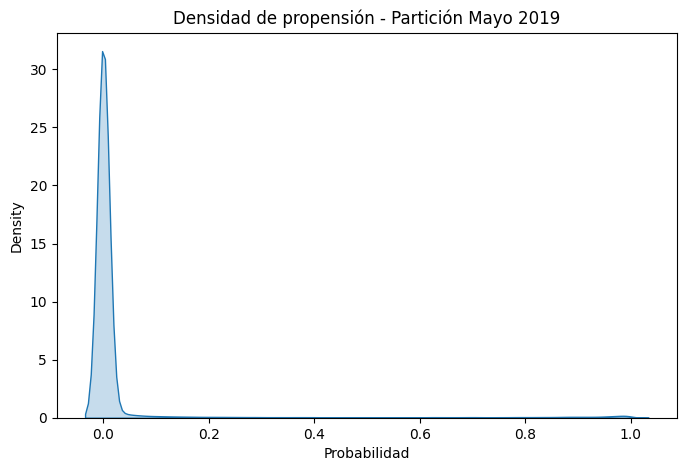

In [56]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.kdeplot(df_scored["proba"], fill=True)
plt.title("Densidad de propensión - Partición Mayo 2019")
plt.xlabel("Probabilidad")
plt.show()

In [57]:
# importamos el dataframe de products para ver quienes tienen algún producto de inversión
df_customer_products = pd.read_csv('../data/datasets_TFM + diccionario/customer_products.csv', sep=',')
df_customer_products.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
df_customer_products_last_partition = df_customer_products[df_customer_products["pk_partition"]==df_customer_products["pk_partition"].max()]

In [58]:
products = ['short_term_deposit', 'funds', 'securities', 'long_term_deposit']
df_customer_products_last_partition = df_customer_products_last_partition[['pk_cid']+products].drop_duplicates()
df_customer_products_last_partition['have_inversion_products'] = df_customer_products_last_partition[products].sum(axis=1)

In [59]:
df_customer_products_last_partition.have_inversion_products.value_counts()

have_inversion_products
0    434382
1      8026
2       552
3        35
Name: count, dtype: int64

Importante tener en cuenta:

- A 434382 clientes "se les va a poder vender" cualquier producto de inversión.
- 8026 clientes ya tienen uno, se le pueden vender 3.
- 552 ya tienen 2, se les puede vender 4
- 35 clientes ya tienen 3, se les puede todavía vender el último que les quede.

In [60]:
df_scored = df_scored.merge(df_customer_products_last_partition, on='pk_cid', how='left')

In [61]:
df_scored_final = df_scored.copy()

In [62]:
def assign_segment(proba):
    if proba >= 0.8:
        return "Top"
    elif proba >= 0.6:
        return "High"
    elif proba >= 0.5:
        return "Medium"
    elif proba >= 0.4:
        return "Mid-Low"
    else:
        return "Low"


df_scored_final["propensity_segment"] = df_scored_final["proba"].apply(assign_segment)
# df_scored_final = df_scored_final[["pk_cid", "proba", "propensity_segment"]].rename(columns={"proba": "propensity_score"})
df_scored_final = df_scored_final[["pk_cid",'short_term_deposit', 'funds', 'securities', 'long_term_deposit', 'have_inversion_products', "proba", "propensity_segment"]].rename(columns={"proba": "propensity_score"})


print(df_scored_final["propensity_segment"].value_counts())
print("-----------------------")
print(df_scored_final["propensity_segment"].value_counts(normalize=True))

propensity_segment
Low        415425
Top          8027
High         4157
Mid-Low      1936
Medium       1819
Name: count, dtype: int64
-----------------------
propensity_segment
Low       0.96
Top       0.02
High      0.01
Mid-Low   0.00
Medium    0.00
Name: proportion, dtype: float64


In [63]:
df_scored_final.head()

,pk_cid,short_term_deposit,funds,securities,long_term_deposit,have_inversion_products,propensity_score,propensity_segment
0,1000028,0,0,0,0,0,0.00,Low
1,1000096,0,0,0,0,0,0.00,Low
2,1000113,0,0,0,0,0,0.00,Low
3,1000130,0,0,0,0,0,0.00,Low
4,1000157,0,0,0,0,0,0.00,Low


In [64]:
# Inversion Family
df_scored_final.groupby("propensity_segment")["propensity_score"].agg(["count", "mean", "std", "min", "max"])

,count,mean,std,min,max
propensity_segment,,,,,
High,4157,0.70,0.06,0.60,0.80
Low,415425,0.01,0.04,0.00,0.40
Medium,1819,0.55,0.03,0.50,0.60
Mid-Low,1936,0.45,0.03,0.40,0.50
Top,8027,0.92,0.06,0.80,1.00


In [65]:
df_scored_final.to_csv('data/processed/df_inversion_family_scored.csv')